# DATA 501 — Python Module 1 Project
## Ride Knox, One Year Later: "Did the Day Pass Work?"
**Name:** *Zaharia Selman*

**NetID:** *zselman*

---


## Part A.1 — Intake of the 2026 data

In [8]:
import pandas as pd
#print("pandas version:", pd.__version__)

In [9]:
## Intake of 2026 data - trips Csv
# New Trips loaded
trips = pd.read_csv("trips_2025.csv")
new_trips = pd.read_csv("trips_2026_h1.csv")

# Display first 5 rows of new_trips
new_trips.head()

# Row count in new_trips
print(f"The file contains {len(new_trips)} rows.") #137,341

The file contains 137341 rows.


In [10]:
## Intake of 2026 data - stations Excel
# Old and New Stations loaded
old_stations = pd.read_excel("stations.xlsx", sheet_name=0)
new_stations = pd.read_excel("stations_2026.xlsx", sheet_name=0)

# Display first 5 rows of new_stations
new_stations.head()

# Row count in new_trips
print(f"The file contains {len(new_stations)} rows.")

The file contains 25 rows.


In [11]:
## How Big are the Files
print(new_trips.shape)
print(new_stations.shape)

(137341, 8)
(25, 7)


In [12]:
## Columns and Types
new_stations.info()
new_stations.dtypes

new_trips.info()
new_trips.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   station_id      25 non-null     object 
 1   station_name    25 non-null     object 
 2   neighborhood    25 non-null     object 
 3   latitude        25 non-null     float64
 4   longitude       25 non-null     float64
 5   docks           25 non-null     int64  
 6   year_installed  25 non-null     int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 1.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137341 entries, 0 to 137340
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   trip_id             137341 non-null  object
 1   start_time          137341 non-null  object
 2   end_time            136537 non-null  object
 3   start_station_id    137341 non-null  object
 4   start_station_name  13

trip_id               object
start_time            object
end_time              object
start_station_id      object
start_station_name    object
end_station_id        object
rider_type            object
bike_type             object
dtype: object

**Below is what I have learned so far from the *new* files:**
- The new trips file (January-June 2026 trips) has 137,341 rows with the same 8 columns that we've encountered in the 2025 files.
- In the trips file, there are two columns that have null results mostly dealing with the end trip details (end_time, end_station_id).
- Lastly in the trips file, start_time and end_time are objects instead of timestamps so this will be reloaded to make them the appropriate datatypes.
  
- The new stations file (updated station directory) has 25 rows, with the same 7 columns that we've encountered in the 2025 files.
- In the stations file, there are no null results and all data types seem to be appropriate for what each column is.

In [13]:
## Reload trips with correct timestamp datatypes
trips = pd.read_csv("trips_2025.csv", parse_dates=["start_time", "end_time"])
new_trips = pd.read_csv("trips_2026_h1.csv", parse_dates=["start_time", "end_time"])
new_trips.dtypes

trip_id                       object
start_time            datetime64[ns]
end_time              datetime64[ns]
start_station_id              object
start_station_name            object
end_station_id                object
rider_type                    object
bike_type                     object
dtype: object

In [14]:
## Missing Values
new_trips.isna().sum() #804 missing in end_time and 3999 missing in end_station_id

end_station_missing = new_trips["end_station_id"].isna().sum()
percent_missing_stat = (end_station_missing/len(new_trips))*100
print(f"The end station id column is missing {percent_missing_stat:.3}% of all trips.")

end_time_missing = new_trips["end_time"].isna().sum()
percent_missing_time = (end_time_missing/len(new_trips))*100
print(f"The end time column is missing {percent_missing_time:.3}% of all trips.")

The end station id column is missing 2.91% of all trips.
The end time column is missing 0.585% of all trips.


In [15]:
## Values in Each Column
new_trips["rider_type"].unique() #Not good for day passers
new_trips["start_station_name"].unique() #Not good
new_trips["bike_type"].unique() #Good
new_trips["start_station_id"].nunique() #Good
new_trips["end_station_id"].nunique() #Good
new_trips["end_station_id"].unique() #Extra end station (than start_station_id) that is nan!

array(['S04', 'S11', 'S02', 'S21', 'S07', 'S09', 'S03', 'S12', 'S08',
       'S06', 'S01', 'S17', 'S10', 'S22', 'S05', 'S13', 'S14', 'S15',
       'S18', nan, 'S23', 'S24', 'S20', 'S19', 'S16', 'S25'], dtype=object)

In [16]:
## Duplicates
new_trips.duplicated().sum() #350 duplicates
new_stations.duplicated().sum() #0 duplicates

np.int64(0)

In [17]:
## Typical Values
new_stations["docks"].describe() #Good
new_stations["year_installed"].describe() #Good

count      25.000000
mean     2023.160000
std         1.143095
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2026.000000
Name: year_installed, dtype: float64

**Within our trips file, now we have learned that:**
- There are some missing values in two columns within our trips dataset (end station id and end time)
- There are seemingly more rider types present in our data than there really are. There are multiple spellings for the day pass riders.
- The bike type seems to be accurate (two bike types: electric and  classic)
- There are 350 duplicated rows so seemingly 136,991 valid rows instead of 137,341. There are no duplicate rows in the new stations file.
- There is a null end station id that does not appear in the dataset, making the number of unique start stations, end stations (both from the trips file), and station ids (from the stations file) equal. 

## Part A.2 — Cleaning of the 2026 data (with audit trail)

In [18]:
## Dropping Duplicates (trips file only)
new_trips.duplicated(keep=False).sum()

# Dropped duplicates, keeping the first copy
trips = trips.drop_duplicates(keep='first')
new_trips = new_trips.drop_duplicates(keep='first')

print(trips.shape)
print(new_trips.shape)

(250000, 8)
(136991, 8)


**Audit Trail** *Removing duplicates (uninformative extra details) leaves us with the same amount of columns but 136,991 rows in the 2026 trips file (137341 → 136,991). Dropping duplicates from the 2025 trips file also leaves us with 250,000 rows (250,600 → 250,000). I decided to drop the last occurrence instead of the first (like done here) to preserve hopefully the original entry.*

In [19]:
## Remove trips starting at S99 and print the new shape
trips = trips[trips["start_station_id"] != "S99"]
trips.shape

## Text Cleanup for Rider Types
trips["rider_type"] = trips["rider_type"].str.strip().str.title()
trips["rider_type"].value_counts()

new_trips["rider_type"] = new_trips["rider_type"].str.strip().str.title()
new_trips["rider_type"].value_counts() #Day Pass still in two categories

new_trips["rider_type"] = new_trips["rider_type"].str.replace("_", " ")
new_trips["rider_type"].value_counts()

## Text Cleanup for Station Names
merged_25 = pd.merge(
    trips, old_stations,
    left_on="start_station_id", right_on="station_id",
    how="left"
)

merged_26 = pd.merge(
    new_trips, new_stations,
    left_on="start_station_id", right_on="station_id",
    how="left"
)

merged_26["station_name"].value_counts()
merged_26.info()
merged_25["station_name"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136991 entries, 0 to 136990
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   trip_id             136991 non-null  object        
 1   start_time          136991 non-null  datetime64[ns]
 2   end_time            136191 non-null  datetime64[ns]
 3   start_station_id    136991 non-null  object        
 4   start_station_name  136991 non-null  object        
 5   end_station_id      133001 non-null  object        
 6   rider_type          136991 non-null  object        
 7   bike_type           136991 non-null  object        
 8   station_id          136991 non-null  object        
 9   station_name        136991 non-null  object        
 10  neighborhood        136991 non-null  object        
 11  latitude            136991 non-null  float64       
 12  longitude           136991 non-null  float64       
 13  docks               136991 no

station_name
Hodges Library               26058
Student Union - UT           24959
Market Square                22606
Cumberland Ave & 17th St     18934
Gay Street & Union Ave       16542
World's Fair Park            15398
Old City - Jackson Ave       14269
The Hill - Ayres Hall        14132
Neyland Stadium              12992
Krutch Park                  10612
Fort Sanders - Laurel Ave     9474
South Waterfront              8305
Ag Campus - Morgan Hall       7255
Happy Holler                  7117
Tyson Park                    6651
Second Creek Greenway         6057
Broadway & Central            5267
Fourth & Gill                 4681
Ijams Nature Center           4250
Suttree Landing Park          3776
Zoo Knoxville                 3537
Caswell Park                  2835
Bearden - Kingston Pike       2095
Sequoyah Hills Park           1935
Name: count, dtype: int64

**File Updates** *Removing the non-existing station (S99) leaves us with 249,737 rows (250,000 → 249,737). The appropriate unique values for rider type and station names are in both data sets now. We have merged all of the data from 2026 with the new stations directory to populate the appropriate station names. Therefore, we have the same number of rows, but now 19 columns.*

In [ ]:
## Missing End Station Ids
merged_26["end_station_id"].isna().sum()

# Create a boolean column to flag rows that aren't missing an id
merged_26["has_end_id"] = ~merged_26["end_station_id"].isna()
merged_25["has_end_id"] = ~merged_25["end_station_id"].isna()

## Missing End Times
merged_26["end_time"].isna().sum()
merged_26["has_end_time"] = ~merged_26["end_time"].isna()

## Verify: True count + missing count == total rows
print((merged_26["has_end_id"] == True).sum() + merged_26["end_station_id"].isna().sum() == len(merged_26))#Good
print((merged_26["has_end_time"] == True).sum() + merged_26["end_time"].isna().sum() == len(merged_26)) #Good
print((merged_25["has_end_id"] == True).sum() + merged_25["end_station_id"].isna().sum() == len(merged_25)) #Good
#print(merged_25["end_station_id"].isna().sum())

True
True
True
3726


**File Updates** *No changes to the number of rows, but we have now appropriately flagged those data observations that are missing end station ids (for the 2025 and 2026 files) and end times (for the 2026 file only) to appropriately address them at a later time. I chose to flag these values rather than dropping them, because they may represent valid operational issues that need to be addressed by the team.*

In [21]:
## Duration Column
merged_26["duration_min"] = ((merged_26["end_time"] - merged_26["start_time"]).dt.total_seconds()) / 60 #convert seconds to minutes
merged_25["duration_min"] = ((merged_25["end_time"] - merged_25["start_time"]).dt.total_seconds()) / 60

merged_26["duration_min"].describe()

count    136191.000000
mean         23.178375
std         142.383385
min         -92.616667
25%           9.266667
50%          14.116667
75%          21.816667
max        4784.733333
Name: duration_min, dtype: float64

**File Updates** *Unfortunately, we have durations that don't make sense/are impossible, so we will clean those in the next block of code below following the same restrictions/thresholds from the 2025 data. I have chosen to drop/filter out these rows instead of flagging them like with the missing observations from above because they will never provide valuable information to answer our questions since they are impossible values.*

In [22]:
## Filter to plausible trips (2 min to 12 hours)
merged_25 = merged_25[(merged_25["duration_min"] >= 1) & (merged_25["duration_min"] <= 720)]
merged_26 = merged_26[(merged_26["duration_min"] >= 1) & (merged_26["duration_min"] <= 720)]
print(merged_25.shape)
print(merged_26.shape)

(247967, 17)
(135611, 18)


**Audit Trail** *Filtering out impossible trips leaves us with 247,844 rows (249,737 → 247,844) in the 2025 trips file and 135,545 rows (136,991 → 135,545) for the 2026 trips file.*

In [23]:
## Timestamps
merged_26["year"] = merged_26["start_time"].dt.year
merged_26["month"] = merged_26["start_time"].dt.month
merged_26["hour"] = merged_26["start_time"].dt.hour
merged_26["day_name"] = merged_26["start_time"].dt.day_name()
merged_26["is_weekday"] = merged_26["day_name"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])

merged_25["year"] = merged_25["start_time"].dt.year
merged_25["month"] = merged_25["start_time"].dt.month
merged_25["hour"] = merged_25["start_time"].dt.hour
merged_25["day_name"] = merged_25["start_time"].dt.day_name()
merged_25["is_weekday"] = merged_25["day_name"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])

## Part B — The recovery question

*To answer if non-member ridership improved, we must compare the same months across the two years appropriately accounting for when the price increase occurred and when the Day Pass option was added.*
1. Below, I first confirm that we lost Casual riders from Jan - Feb 2025 and Jan - Feb 2026 (the impact of the price increase before the Day Pass option).
2. Then, I will compare Casual riders from March-June 2025 (the appropriate baseline) with non-member riders (Casual and Day Pass riders) from March-June 2026 to compare how the Day Pass has impacted non-member riders even after the price increase. Comparing across the same time period will allow us to control for seasonal changes in rider types.
   - This second comparison will leaves us with 105,962 rows for the 2025 data file (247,844 → 105,962). This leaves us with 113,562 rows in the 2026 data (135,545 → 113,562). I will compare the **number** and **median duration** of trips taken by different rider types from month-to-month and year-to-year.

In [24]:
## Confirm loss in Casual riders
confirm_25 = merged_25[merged_25["month"].isin([1,2])]
confirm_26 = merged_26[merged_26["month"].isin([1,2])]

print(f"Number of each rider type in January-February 2025: {confirm_25["rider_type"].value_counts()}")
print(f"\nNumber of each rider type in January-February 2026: {confirm_26["rider_type"].value_counts()}")

Number of each rider type in January-February 2025: rider_type
Member    13706
Casual    10365
Name: count, dtype: int64

Number of each rider type in January-February 2026: rider_type
Member    14569
Casual     7429
Name: count, dtype: int64


In [25]:
# Make a new dataframe with just March (3) - June (6) 2025 data (when non-member riders started declining because of price increase)
new_merged_25 = merged_25[merged_25["month"].isin([3, 4, 5, 6])]
new_merged_25["month"].value_counts()

# Make a new dataframe with just March (3) - June (6) 2026 (when the Day Pass was added)
comp_merg_26 = merged_26[(merged_26["month"] != 1) & (merged_26["month"] != 2)]

new_merged_25.info()
comp_merg_26.info()

new_merged_25.shape #105,962 rows, 21 columns
comp_merg_26.shape #113,562 rows, 22 columns (has_end_time)

<class 'pandas.core.frame.DataFrame'>
Index: 106013 entries, 24245 to 131010
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   trip_id             106013 non-null  object        
 1   start_time          106013 non-null  datetime64[ns]
 2   end_time            106013 non-null  datetime64[ns]
 3   start_station_id    106013 non-null  object        
 4   start_station_name  106013 non-null  object        
 5   end_station_id      104371 non-null  object        
 6   rider_type          106013 non-null  object        
 7   bike_type           106013 non-null  object        
 8   station_id          106013 non-null  object        
 9   station_name        106013 non-null  object        
 10  neighborhood        106013 non-null  object        
 11  latitude            106013 non-null  float64       
 12  longitude           106013 non-null  float64       
 13  docks               106013 non

(113613, 23)

In [26]:
print(f"Number of each rider type in March-June 2025: {new_merged_25["rider_type"].value_counts()}")
print(f"\nNumber of each rider type in March-June 2026: {comp_merg_26["rider_type"].value_counts()}")

Number of each rider type in March-June 2025: rider_type
Member    59180
Casual    46833
Name: count, dtype: int64

Number of each rider type in March-June 2026: rider_type
Member      65042
Casual      37685
Day Pass    10886
Name: count, dtype: int64


**File Updates** *Because the manager's question asks specifically about non-members, I will count Day Passers as non-members. At first glance, the addition of 10,886 Day Pass riders seemed to increase the total number of non-member riders by 1,737 riders from March - June 2026. However, non-member riders (casual only) were 44.2% of total trips in March-June 2025 (before the price increase) and decreased to 42.8% of total trips in March-June 2026 (both casual and day pass riders after the price increase).*

In [27]:
### GroupBy Summaries
## Median trip count and duration for each rider type across months in 2025
# Used AI here - couldn't figure out how to groupby rider type as well (needed to add inside groupby(), not agg()).
print("2025 Data")
new_merged_25.groupby(["month", "rider_type"]).agg(
    num_trips = ("trip_id", "count"),
    med_duration = ("duration_min", "median")
)

# new_merged_25.groupby('month')['rider_type'].count()
# new_merged_25.groupby('month')['trip_id'].sum()
# plt.hist(new_merged_25["duration_min"], bins=50)

2025 Data


num_trips  med_duration
month rider_type                         
3     Casual           8569     18.850000
      Member          11156     11.700000
4     Casual          11241     19.050000
      Member          14155     11.650000
5     Casual          13207     19.050000
      Member          16406     11.633333
6     Casual          13816     19.016667
      Member          17463     11.616667

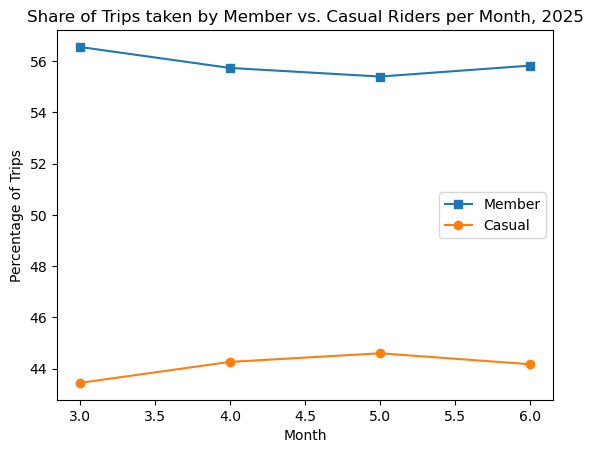

In [28]:
import matplotlib.pyplot as plt

share_riders_25 = (new_merged_25.groupby("month")["rider_type"].value_counts(normalize=True).unstack() * 100).round(4)
# print(share_riders_25)

plt.plot(share_riders_25.index, share_riders_25["Member"], label="Member", marker="s")
plt.plot(share_riders_25.index, share_riders_25["Casual"], label="Casual", marker="o")
plt.title("Share of Trips taken by Member vs. Casual Riders per Month, 2025")
plt.xlabel("Month"); plt.ylabel("Percentage of Trips"); 
plt.legend()
plt.savefig("share_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
### A different way to do the simplified code above!!!
## Percentage of total trips that were taken by Casual riders per month IN 2025 
# print("Percentage of total trips that were taken by Casual riders from March-June 2025")
# print(new_merged_25[new_merged_25["rider_type"] == 'Casual'].groupby("month").size() / new_merged_25.groupby("month")['rider_type'].size() * 100)

# print("\nPercentage of total trips that were taken by Member riders from March-June 2025")
# new_merged_25[new_merged_25["rider_type"] == 'Member'].groupby("month").size() / new_merged_25.groupby("month")['rider_type'].size() * 100
# monthly_cas_25 = new_merged_25[new_merged_25["rider_type"] == 'Casual'].groupby("month").size() / new_merged_25.groupby("month")['rider_type'].size() * 100

# monthly_mem_25 = new_merged_25[new_merged_25["rider_type"] == 'Member'].groupby("month").size() / new_merged_25.groupby("month")['rider_type'].size() * 100

In [30]:
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10,6))
# plt.plot(monthly_mem_25.index, monthly_mem_25.values, label="Member", marker='o')
# plt.title("Percentage of Trips taken by Member riders from March - June 2025")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Member Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

In [31]:
# plt.figure(figsize=(10,6))
# plt.plot(monthly_cas_25.index, monthly_cas_25.values, label="Casual", marker="o", color='orange')
# plt.title("Percentage of Trips taken by Casual riders from March - June 2025")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Casual Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

**File Updates: 2025 Data** *As we know and can see here, the percentage of Casual riders was increasing slowly and then declined slightly before the price increase even happened in July 2025. However, the median duration of casual riders was about 19.0 minutes/trip. Also during this time, the percentage of Member riders was decreasing until June 2025 and their average trip duration was about 11.7 minutes/trip.*

In [32]:
## Average trip count and duration for each rider type across months in 2026
print("2026 Data")
comp_merg_26.groupby(["month", "rider_type"]).agg(
    num_trips = ("trip_id", "count"),
    med_duration = ("duration_min", "median")
)
# plt.hist(comp_merg_26["duration_min"], bins=50)

2026 Data


num_trips  med_duration
month rider_type                         
3     Casual           6697     18.783333
      Day Pass         1111     19.650000
      Member          12348     11.583333
4     Casual           8898     19.116667
      Day Pass         2240     20.783333
      Member          15369     11.633333
5     Casual          10746     19.066667
      Day Pass         3418     20.425000
      Member          18000     11.716667
6     Casual          11344     19.250000
      Day Pass         4117     20.716667
      Member          19325     11.683333

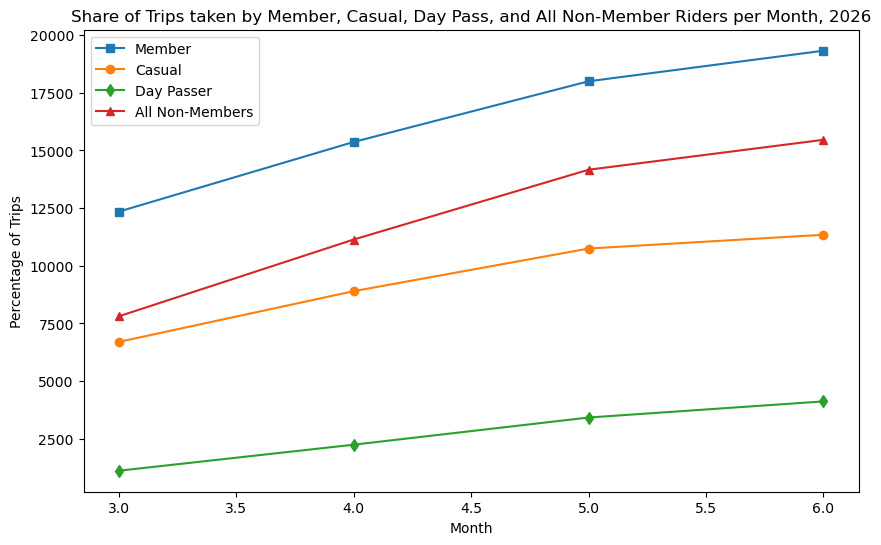

In [33]:

share_riders_26 = (comp_merg_26.groupby("month")["rider_type"].value_counts().unstack()).round(4)
# print(share_riders_26)
share_riders_26["All Non Members"] = share_riders_26["Casual"] + share_riders_26["Day Pass"]
# # print(share_riders_26)

plt.figure(figsize=(10,6))
plt.plot(share_riders_26.index, share_riders_26["Member"], label="Member", marker="s")
plt.plot(share_riders_26.index, share_riders_26["Casual"], label="Casual", marker="o")
plt.plot(share_riders_26.index, share_riders_26["Day Pass"], label="Day Passer", marker="d")
plt.plot(share_riders_26.index, share_riders_26["All Non Members"], label="All Non-Members", marker="^")
plt.title("Share of Trips taken by Member, Casual, Day Pass, and All Non-Member Riders per Month, 2026")
plt.xlabel("Month"); plt.ylabel("Percentage of Trips"); 
plt.legend()
plt.savefig("share_by_rider_type_2026.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
### A different way to do the simplified code above!!!
## Percentage of total trips that were taken by Casual riders per month
# print("Percentage of total trips that were taken by Casual riders from March - July 2026")
# casual_perc = (comp_merg_26[comp_merg_26["rider_type"] == 'Casual'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size()) * 100
# print(casual_perc)

# print("\nPercentage of total trips that were taken by Day Pass riders from March - July 2026")
# day_pass_perc = (comp_merg_26[comp_merg_26["rider_type"] == 'Day Pass'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size()) * 100
# print(day_pass_perc)

# print("\nPercentage of total trips that were taken by Casual AND Day Pass riders from March - July 2026")
# print(casual_perc + day_pass_perc)

# print("\nPercentage of total trips that were taken by Member riders from March - July 2026")
# comp_merg_26[comp_merg_26["rider_type"] == 'Member'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size() * 100

# monthly_mem_26 = (comp_merg_26[comp_merg_26["rider_type"] == 'Member'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size()) * 100
# monthly_cas_26 = (comp_merg_26[comp_merg_26["rider_type"] == 'Casual'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size()) * 100
# monthly_day_26 = (comp_merg_26[comp_merg_26["rider_type"] == 'Day Pass'].groupby("month").size() / comp_merg_26.groupby("month")['rider_type'].size()) * 100
# all_non_mem_26 = monthly_cas_26 + monthly_day_26

# plt.figure(figsize=(10,6))
# plt.plot(monthly_mem_26.index, monthly_mem_26.values, label="Member", marker='o')
# plt.title("Percentage of Trips taken by Member riders from March - June 2026")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Total Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

In [35]:
# plt.figure(figsize=(10,6))
# plt.plot(monthly_cas_26.index, monthly_cas_26.values, label="Casual", marker="o", color='orange')
# plt.title("Percentage of Trips taken by Casual riders from March - June 2026")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Casual Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

In [36]:
# plt.figure(figsize=(10,6))
# plt.plot(monthly_day_26.index, monthly_day_26.values, label="Day Passers", marker="o", color='black')
# plt.title("Percentage of Trips taken by Day Pass riders from March - June 2026")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Day Pass Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

In [37]:
# plt.figure(figsize=(10,6))
# plt.plot(all_non_mem_26.index, all_non_mem_26.values, label="Non-member Riders", marker="o", color='green')
# plt.title("Percentage of Trips taken by Non-member riders (Casual and Day Pass riders) from March - June 2026")
# plt.xlabel("Month")
# plt.ylabel("Percentage of Non-member Riders")
# plt.legend()
# # plt.savefig("monthly_by_rider_type_2025.png", dpi=150, bbox_inches="tight")
# plt.show()

**File Updates: 2026 Data**
- *After the Day Pass was added in March 2026, the percentage of total trips taken by Casual members fluctuated slightly (increased then declined). However, the total percentage of all non-members (Casual **and** Day Passers), steadily increased from ~39% in March 2026 to ~44% in June 2026. This can be attributed to the steady increase in riders choosing the Day Passes. See Share of Trips taken by Member, Casual, Day Pass, and All Non-Member Riders per Month, 2026 chart above.*
- *By June 2026, this increase in total non-member riders (casual and day passers) brought the percentage of non-member and member riders almost to a 50/50 split.*
- *Additionally, the median duration of trips for Casual riders and Member riders were consistent with 2025: from 19.0 min to 19.1 min/trip for Casual riders and 11.7 min/trip across both years for Member riders.*
- *Day Pass riders had the highest median duration at 20.6 min/trip!*

**File Updates:** *the manager can answer "did it work?" and understands what that answer depends on.* 

Looking at just the average number of trips for casual riders may be deceiving. In comparing March-June 2025 to March-June 2026 more closely, the percentage of **total** trips by non-members seems to be growing back to the pre-casual rider status before the price increase. The addition of the Day Pass seems to have been a good decision.
- In March 2025, ~43% (19,716 total trips) of trips were taken by non-member riders (casual only). In March 2026, only ~38% (20,145 total trips) of trips were taken by non-member riders (casual and Day Passers).

- In April 2025, ~44% (25,388 total trips) of trips were taken by non-members, while in April 2026, only ~42% (26,498 total trips) of trips were taken by non-members.

- In May 2025, ~45% (29,598 total trips) of trips were taken by non-members, while in May 2026, only ~44% (32,148 total trips) of trips were taken by non-members.

- Lastly, in June 2025, ~44% (31,260 total trips) of trips were taken by non-members, while in June 2026, ~44% (34,771 total trips) of trips were taken by non-members.

- It seems like we need to continue to monitor the impact of the Day Pass on riders for a few more months, to see if it truly continues to increase.

## Part C — The capacity question

In [38]:
## Have to re-add code after merge and re-merge on END stations to get appropriate arrival status for each station
# Create a boolean column to flag rows that aren't missing an id
trips["has_end_id"] = ~trips["end_station_id"].isna()
new_trips["has_end_id"] = ~new_trips["end_station_id"].isna()

## Missing End Times
new_trips["end_time"].isna().sum()
new_trips["has_end_time"] = ~new_trips["end_time"].isna()

## Verify: True count + missing count == total rows
(new_trips["has_end_id"] == True).sum() + new_trips["end_station_id"].isna().sum() #Good
(new_trips["has_end_time"] == True).sum() + new_trips["end_time"].isna().sum() #Good
(trips["has_end_id"] == True).sum() + trips["end_station_id"].isna().sum() #Good

np.int64(249737)

In [39]:
end_25 = trips[trips["has_end_id"] == True]
end_26 = new_trips[(new_trips["has_end_id"] == True) & (new_trips["has_end_time"] == True)]

end_merged_25 = pd.merge(
    end_25, old_stations,
    left_on="end_station_id", right_on="station_id",
    how="left"
)

end_merged_26 = pd.merge(
    end_26, new_stations,
    left_on="end_station_id", right_on="station_id",
    how="left"
)

# Verify row counts match; verify no missing station info
# print(len(end_25))
# print(len(end_merged_25))
# print(len(end_26))
# print(len(end_merged_26))
# print(end_merged_25.isna().sum())
# print(end_merged_26.isna().sum())

In [40]:
## Add Duration Column back
end_merged_26["duration_min"] = ((end_merged_26["end_time"] - end_merged_26["start_time"]).dt.total_seconds()) / 60 #convert seconds to minutes
end_merged_25["duration_min"] = ((end_merged_25["end_time"] - end_merged_25["start_time"]).dt.total_seconds()) / 60

## Filter to plausible trips (2 min to 12 hours)
end_merged_25 = end_merged_25[(end_merged_25["duration_min"] >= 2) & (end_merged_25["duration_min"] <= 720)]
end_merged_26 = end_merged_26[(end_merged_26["duration_min"] >= 2) & (end_merged_26["duration_min"] <= 720)]
print(end_merged_25.shape)
print(end_merged_26.shape)

# ## Add Timestamps back
end_merged_26["year"] = end_merged_26["start_time"].dt.year
end_merged_26["month"] = end_merged_26["start_time"].dt.month
end_merged_26["hour"] = end_merged_26["start_time"].dt.hour
end_merged_26["day_name"] = end_merged_26["start_time"].dt.day_name()
end_merged_26["is_weekday"] = end_merged_26["day_name"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])

end_merged_25["year"] = end_merged_25["start_time"].dt.year
end_merged_25["month"] = end_merged_25["start_time"].dt.month
end_merged_25["hour"] = end_merged_25["start_time"].dt.hour
end_merged_25["day_name"] = end_merged_25["start_time"].dt.day_name()
end_merged_25["is_weekday"] = end_merged_25["day_name"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])

(244120, 17)
(131598, 18)


In [41]:
## 1.	Did the S06/S08 dock expansion relieve pressure?
# Creating new dataframes to account for the new baseline (comparing February 2025 to February 2026)
feb_merg_25 = end_merged_25[end_merged_25["month"].isin([2])]
# feb_merg_25["month"].value_counts()

feb_merg_26 = end_merged_26[end_merged_26["month"].isin([2])]
# feb_merg_26["month"].value_counts()

In [42]:
## Feb 2025 for S06/S08
# Keep only trips with a recorded end station. UPDATE: Done above instead
# end_25 = feb_merg_25[feb_merg_25["has_end_id"] == True]
# print(len(end_25))
# print(end_25['docks'].value_counts())

arr_per_station_25 = (
    feb_merg_25.groupby(["station_id","station_name","neighborhood", "docks"]).size().reset_index(name="trip_count")
)

arr_per_station_25["arrivals_per_dock"] = arr_per_station_25["trip_count"] / arr_per_station_25["docks"]

all_campus_stations_25 = arr_per_station_25[(arr_per_station_25["neighborhood"] == 'UT Campus') | (arr_per_station_25["neighborhood"] == 'UT Ag Campus')]
# arr_per_station_25["percent_trips"] = round(arr_per_station_25["trip_count"] / arr_per_station_25["trip_count"].sum(),4) * 100
# print(all_campus_stations_25["trip_count"].sum())

# all_campus_stations_25["percent_trips"] = round(all_campus_stations_25["trip_count"] / all_campus_stations_25["trip_count"].sum(),4) * 100

all_campus_stations_25.sort_values("arrivals_per_dock", ascending=False)

,station_id,station_name,neighborhood,docks,trip_count,arrivals_per_dock
6,S07,The Hill - Ayres Hall,UT Campus,12,740,61.666667
5,S06,Hodges Library,UT Campus,24,1322,55.083333
7,S08,Student Union - UT,UT Campus,24,1265,52.708333
8,S09,Neyland Stadium,UT Campus,16,685,42.812500
9,S10,Ag Campus - Morgan Hall,UT Ag Campus,12,405,33.750000


Text(0.5, 0, 'Arrivals per Dock')

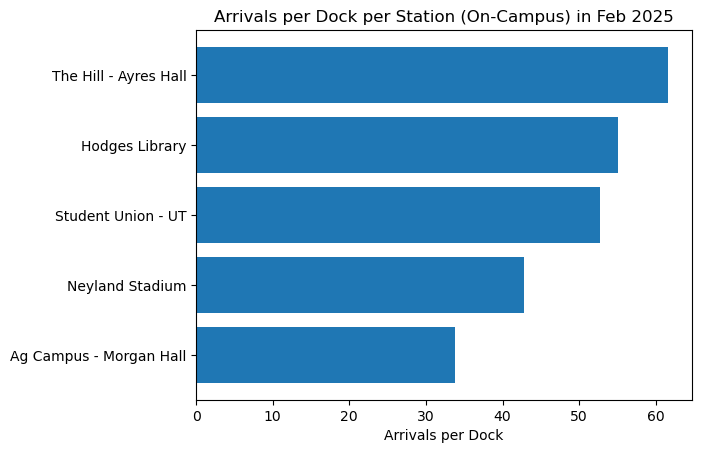

In [43]:
arrivals_hist = all_campus_stations_25.sort_values("arrivals_per_dock", ascending=True)
plt.barh(arrivals_hist["station_name"], arrivals_hist["arrivals_per_dock"])
plt.title("Arrivals per Dock per Station (On-Campus) in Feb 2025")
plt.xlabel("Arrivals per Dock")
# The Hill appears to be more heavily populated (fewer trip count but also fewer docks so more arrivals per dock)

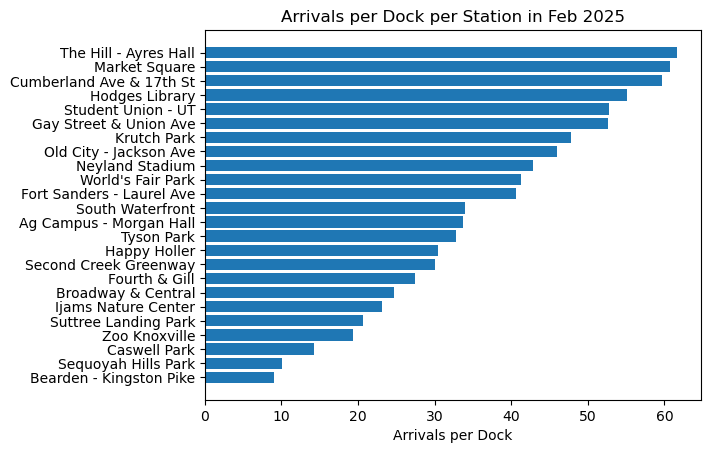

In [44]:
arrivals_hist = arr_per_station_25.sort_values("arrivals_per_dock", ascending=True)
# print(arrivals_hist)
plt.barh(arrivals_hist["station_name"], arrivals_hist["arrivals_per_dock"])
plt.title("Arrivals per Dock per Station in Feb 2025")
plt.xlabel("Arrivals per Dock")
plt.savefig("arrivals_per_dock_2025.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
## Feb 2026 for S06/S08
# Keep only trips with a recorded end station AND end time. UPDATE: Done above instead
# end_26 = feb_merg_26[(feb_merg_26["has_end_id"] == True) & (feb_merg_26["has_end_time"] == True)]

arr_per_station_26 = (
    feb_merg_26.groupby(["station_id","station_name","neighborhood", "docks"]).size().reset_index(name="trip_count")
)

arr_per_station_26["arrivals_per_dock"] = arr_per_station_26["trip_count"] / arr_per_station_26["docks"]

all_campus_stations_26 = arr_per_station_26[(arr_per_station_26["neighborhood"] == 'UT Campus') | (arr_per_station_26["neighborhood"] == 'UT Ag Campus')]
# arr_per_station_26["percent_trips"] = ((arr_per_station_26["trip_count"] / all_campus_stations_26["trip_count"].sum()) * 100).round(4)
# print(all_campus_stations_26["trip_count"].sum())

# all_campus_stations_26["percent_trips"] = ((arr_per_station_26["trip_count"] / all_campus_stations_26["trip_count"].sum()) * 100).round(4)

all_campus_stations_26.sort_values("arrivals_per_dock", ascending=False)

,station_id,station_name,neighborhood,docks,trip_count,arrivals_per_dock
6,S07,The Hill - Ayres Hall,UT Campus,12,617,51.416667
8,S09,Neyland Stadium,UT Campus,16,615,38.437500
5,S06,Hodges Library,UT Campus,32,1195,37.343750
7,S08,Student Union - UT,UT Campus,32,1131,35.343750
9,S10,Ag Campus - Morgan Hall,UT Ag Campus,12,359,29.916667


Text(0.5, 0, 'Arrivals per Dock')

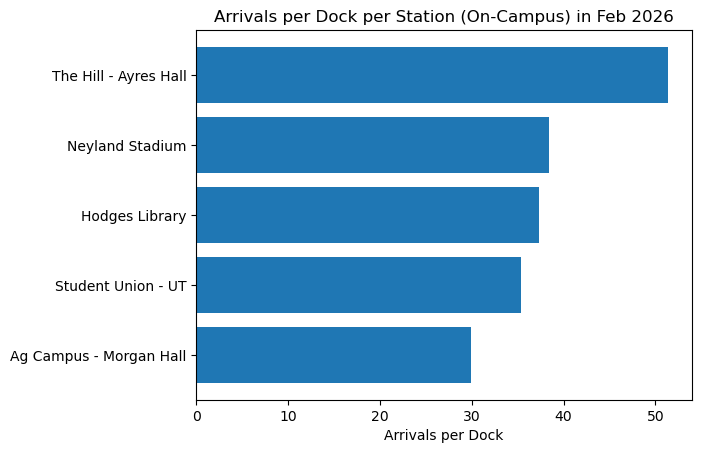

In [46]:
arrivals_hist_26 = all_campus_stations_26.sort_values("arrivals_per_dock", ascending=True)
plt.barh(arrivals_hist_26["station_name"], arrivals_hist_26["arrivals_per_dock"])
plt.title("Arrivals per Dock per Station (On-Campus) in Feb 2026")
plt.xlabel("Arrivals per Dock")

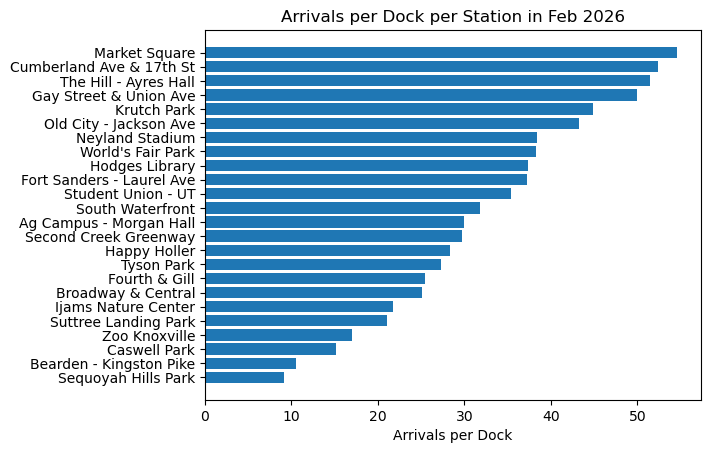

In [47]:
arrivals_hist_26 = arr_per_station_26.sort_values("arrivals_per_dock", ascending=True)
# print(arrivals_hist_26)
plt.barh(arrivals_hist_26["station_name"], arrivals_hist_26["arrivals_per_dock"])
plt.title("Arrivals per Dock per Station in Feb 2026")
plt.xlabel("Arrivals per Dock")
plt.savefig("arrivals_per_dock_2026.png", dpi=150, bbox_inches="tight")
plt.show()

**File Updates** *Here, I chose to not account for when the Day Pass option started being offered (March 2026) so I only compared the change in arrivals per station for S06 and S08 across one month (February).*
- The addition of docks at S06 and S08 seems to have changed the congestion at those sites. After the extra docks were added, the arrivals per dock per station does decline showing possibly some effect of increasing the number of docks at these two stations. See Arrivals per Dock per Station in Feb 2025 **and** 2026 charts.

In [48]:
## 2.	What's the year-two verdict on the 2025 rookie stations, Bearden (S23) and Sequoyah Hills Park (S24); keep, watch, or relocate?
# jan_june_merg_26 = end_merged_26[end_merged_26["month"].isin([1, 2, 3, 4, 5, 6])]
jan_june_merg_25 = merged_25[merged_25["month"].isin([1, 2, 3, 4, 5, 6])]

# jan_june_merg_26 = end_merged_26[end_merged_26["month"].isin([1, 2, 3, 4, 5, 6])]
jan_june_merg_26 = merged_26[merged_26["month"].isin([1, 2, 3, 4, 5, 6])]

print(f"Bearden-Kingston Pike Trips:\n{jan_june_merg_25[jan_june_merg_25["station_name"] == 'Bearden - Kingston Pike'].groupby("month").size()}")
print(f"\nSequoyah Hills Park Trips:\n{jan_june_merg_25[jan_june_merg_25["station_name"] == 'Sequoyah Hills Park'].groupby("month").size()}")

dep_per_station = (
    jan_june_merg_25.groupby(["station_name","neighborhood", "docks"]).size().reset_index(name="trip_count")
)
dep_per_station["dep_per_dock"] = dep_per_station["trip_count"] / dep_per_station["docks"]

dep_per_station.sort_values("dep_per_dock", ascending=False)

Bearden-Kingston Pike Trips:
month
1     87
2    106
3    162
4    203
5    266
6    251
dtype: int64

Sequoyah Hills Park Trips:
month
1     80
2     98
3    159
4    204
5    222
6    219
dtype: int64


,station_name,neighborhood,docks,trip_count,dep_per_dock
20,The Hill - Ayres Hall,UT Campus,12,7461,621.750000
4,Cumberland Ave & 17th St,Fort Sanders,16,9939,621.187500
12,Market Square,Downtown,20,11866,593.300000
9,Hodges Library,UT Campus,24,13538,564.083333
18,Student Union - UT,UT Campus,24,13089,545.375000
7,Gay Street & Union Ave,Downtown,16,8574,535.875000
14,Old City - Jackson Ave,Old City,16,7501,468.812500
11,Krutch Park,Downtown,12,5514,459.500000
13,Neyland Stadium,UT Campus,16,6541,408.812500
5,Fort Sanders - Laurel Ave,Fort Sanders,12,4895,407.916667


In [49]:
## 2.	What's the year-two verdict on the 2025 rookie stations, Bearden (S23) and Sequoyah Hills Park (S24); keep, watch, or relocate?
print(f"Bearden - Kingston Pike Trips:\n {jan_june_merg_26[jan_june_merg_26["station_name"] == 'Bearden - Kingston Pike'].groupby("month").size()}")
print(f"\nSequoyah Hills Park Trips:\n {jan_june_merg_26[jan_june_merg_26["station_name"] == 'Sequoyah Hills Park'].groupby("month").size()}")

dep_per_station_26 = (
    jan_june_merg_26.groupby(["station_name","neighborhood", "docks"]).size().reset_index(name="trip_count")
)
dep_per_station_26["dep_per_dock"] = dep_per_station_26["trip_count"] / dep_per_station_26["docks"]

dep_per_station_26.sort_values("trip_count", ascending=False)

Bearden - Kingston Pike Trips:
 month
1    166
2    220
3    331
4    430
5    553
6    517
dtype: int64

Sequoyah Hills Park Trips:
 month
1     68
2     87
3    149
4    183
5    237
6    254
dtype: int64


,station_name,neighborhood,docks,trip_count,dep_per_dock
13,Market Square,Downtown,20,12360,618.000000
10,Hodges Library,UT Campus,32,12319,384.968750
19,Student Union - UT,UT Campus,32,11901,371.906250
4,Cumberland Ave & 17th St,Fort Sanders,16,8963,560.187500
8,Gay Street & Union Ave,Downtown,16,8927,557.937500
23,World's Fair Park,World's Fair Park,20,8316,415.800000
15,Old City - Jackson Ave,Old City,16,7704,481.500000
21,The Hill - Ayres Hall,UT Campus,12,6854,571.166667
14,Neyland Stadium,UT Campus,16,6803,425.187500
5,Cumberland Ave & 22nd St,Fort Sanders,16,6404,400.250000


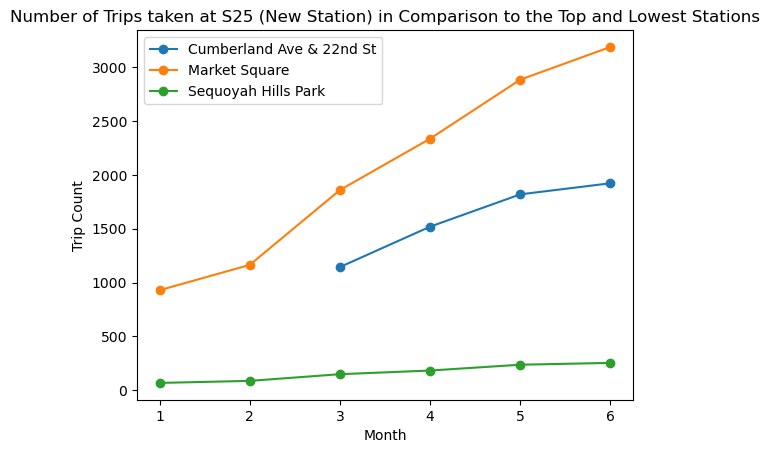

In [50]:
monthly = merged_26.groupby(["month","station_name"]).size().unstack()
# print(monthly)
plt.plot(monthly.index, monthly["Cumberland Ave & 22nd St"], label="Cumberland Ave & 22nd St", marker="o")
plt.plot(monthly.index, monthly["Market Square"], label="Market Square", marker="o") #the overall top station
plt.plot(monthly.index, monthly["Sequoyah Hills Park"], label="Sequoyah Hills Park", marker="o") #the overall lowest station
plt.title("Number of Trips taken at S25 (New Station) in Comparison to the Top and Lowest Stations")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.legend()
plt.savefig("S25_comparison_2026.png", dpi=150, bbox_inches="tight")
plt.show()

**File Updates** *Number of trips steadily increases for both stations, but they both still have some of the lowest stats by the end of June 2026. However, Bearden (S23) appears to be growing more/faster than Sequoyah (S24), as it changes places with Caswell Park Station. It may be worth keeping Bearden to allow it to continue to grow and watching Sequoyah at least until the end of the year to see if anything changes before relocating it. See Number of Trips taken at S25 (New Station) in Comparison to the Top and Lowest Stations chart.*

*From this same data, we can see that the new station Cumberland Ave & 22nd St (S25) seems to be doing very well. It is in the top 10 for both the number of departures per dock and the total number of trips, even though it has only been in operation for 4 months! As the monthly trip counts show in the line graph, there may be a plateau at June that we will need to keep an eye on.*

## Part D — Who are the day-pass riders?

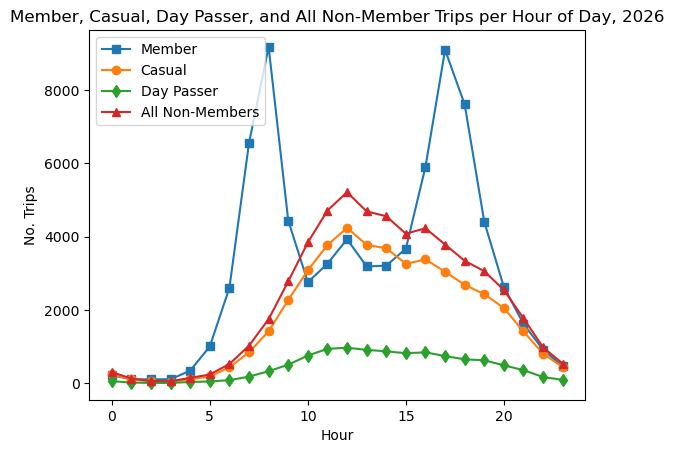

In [51]:
# Station Pressure by Rider Type
has_end_merged_26 = merged_26[(merged_26["has_end_id"] == True) & (merged_26["has_end_time"] == True)]

hourly = has_end_merged_26.groupby(["hour", "rider_type"]).size().unstack()
hourly["All Non Members"] = hourly["Casual"] + hourly["Day Pass"]

plt.plot(hourly.index, hourly["Member"], label="Member", marker="s")
plt.plot(hourly.index, hourly["Casual"], label="Casual", marker="o")
plt.plot(hourly.index, hourly["Day Pass"], label="Day Passer", marker="d")
plt.plot(hourly.index, hourly["All Non Members"], label="All Non-Members", marker="^")
plt.title("Member, Casual, Day Passer, and All Non-Member Trips per Hour of Day, 2026")
plt.xlabel("Hour"); plt.ylabel("No. Trips"); plt.legend()
plt.savefig("trips_per_hour_per_rider_type_2026.png", dpi=150, bbox_inches="tight")
plt.show()

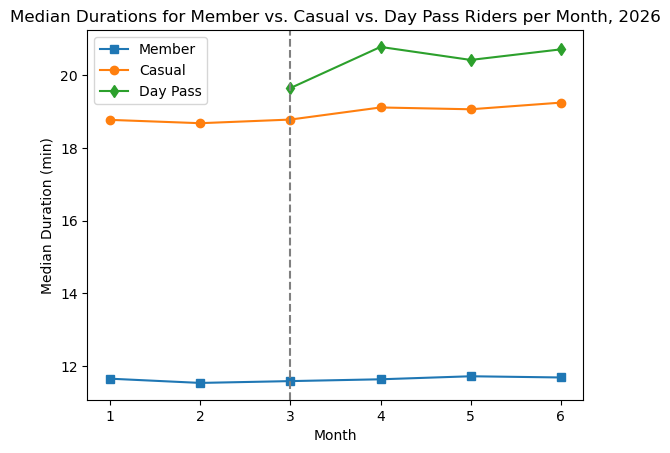

In [52]:
# plt.hist(merged_26["duration_min"], color='orange', bins=12)
merged_26.groupby("rider_type")["duration_min"].median()
duration_comp = merged_26.groupby(["month", "rider_type"])["duration_min"].median().unstack()
# print(duration_comp)

plt.plot(duration_comp.index, duration_comp["Member"], label="Member", marker="s")
plt.plot(duration_comp.index, duration_comp["Casual"], label="Casual", marker="o")
plt.plot(duration_comp.index, duration_comp["Day Pass"], label="Day Pass", marker="d")
plt.axvline(x=3, linestyle="--", color="gray")
plt.title("Median Durations for Member vs. Casual vs. Day Pass Riders per Month, 2026")
plt.xlabel("Month"); plt.ylabel("Median Duration (min)"); 
plt.legend()
plt.savefig("median_duration_per_rider_type_2026.png", dpi=150, bbox_inches="tight")
plt.show()

# plt.hist(merged_26[merged_26["rider_type"] == 'Casual']["duration_min"], color='orange', bins=50)
# plt.show()
# plt.hist(merged_26[merged_26["rider_type"] == 'Member']["duration_min"], color='blue', bins=50)
# plt.show()
# plt.hist(merged_26[merged_26["rider_type"] == 'Day Pass']["duration_min"], color='red', bins=50)

**Caption text:** *This figure represents the percentage of Member, Casual, and Day Pass riders that Ride Knox served from January - June 2026. The vertical line represents when the Day Pass rider option started (March 2026).*

**File Updates**: *clearly stated behavioral verdict, with the evidence and its limits.*
- Although the proportion of Day Pass riders is significantly lower than Member or Casual riders from March - June 2026, this is the only proportion that shows a continual increase from March - June 2026. During this same time period, the proportion of Members decline and the proportion of Casual riders stays consistent/flat (not much growth or decline). See the chart titled, "Share of Trips taken by Member, Casual, Day Passer, and All Non-Member Riders per Month, 2026".
- In assessing the number of trips Day Pass riders are taking per hour, the pattern looks similar to those of Casual riders where most rides are being taken in the afternoon (see Member vs. Casual vs. Day Passer Trips per Hour of Day, 2026 chart)
- The typical trip by a Day Pass rider is also consistently longer (in minutes) than Casual or Member riders (see Median Durations for Member vs. Casual vs. Day Pass Riders per Month, 2026 chart).
- All of this leads to evidence for the Day Pass help recover lost Casual riders, but not quite cannibalizing membership as Day Pass riders don't take trips during similar times of the day or compare in proportion of riders as Members, however this verdict is limited by the lack of data available for Day Pass riders. More time is needed to see how Day Pass riders continue to grow or not.

## Reflection and AI disclosure
1. ***Reflection**: which single decision in this project could most change your conclusions if you'd decided differently, and how do you know?*
   - I believe comparing the data from 2025 and 2026 across different baseline months would have changed my conclusions the most. For example, in the beginning of this project, I had the idea to compare July-October 2025 with March-June 2026 because July 2025 is when the price increase occurred and March 2026 is when the Day Pass option started. However, because there are variables that would not give a fair comparison (like seasonal variations between these sets of months), the best option is to compare March-June 2025 (when there was no Day Pass option and no price increase) to March-June 2026 (when there was the price increase and the Day Pass option) to determine if the Day Pass option off-set the loss of casual riders. After comparing Jan-Feb 2025 (before price increase) to Jan-Feb 2026 (after price increase, but before Day Pass option), we did confirm that the pay increase affected our casual riders, so I believe the best way to addresses if the Day Pass option caused a substantial effect is by comparing March-June across years.

  
2. ***AI disclosure**: describe any use of generative AI tools, or state "No generative AI tools were used." AI-generated output must not be submitted verbatim; all submitted work must reflect your own understanding and judgment. Example: "I used a generative AI tool to debug a merge and to proofread my memo. All analysis decisions, code, and conclusions are my own." An accurate disclosure never costs points. A missing or false one is an academic-integrity matter.*
   - I used Google to look up certain function arguments and investigate if there was a way to include percentages in the aggregate function (although unsuccessful). I also had trouble debugging the indexing for extracting values from the groupby dataframes to make the visualizations so I used Google to help with this. Otherwise, all analysis decisions, code, and conclusions are my own, though. 



## Part E The memo 

**TO:** Ride Knox, Board  
**FROM:** Zaharia Selman, Ride Knox Data Scientist  
**DATE:** September 14, 2026  
**SUBJECT:** Python Module Project, One Year Later: "Did the Day Pass Work?" 

---

## Bottom Line
**The Day Pass brought casual riders back. The dock expansion and new station fix the campus crunch. One out of two idle stations from 2025 seem to still be sitting idle.**


## Evidence
(1) Looking at just the average number of trips for casual riders may be deceiving. In comparing March-June 2025 to March-June 2026 more closely, the percentage of total trips by non-members increases.
Comparing March 2025 (before price increase) to March 2026 (after price increase, and after Day Pass was introduced), ~43% (19,716 total trips) to ~38% (20,145 total trips) of trips were taken by non-members.
Comparing June 2025 to June 2026, ~44% (31,260 total trips) to ~44% (34,771 total trips) of trips were taken by non-members. Additionally, the median duration of trips for Casual riders and Member riders was consistent from 2025 - 2026. Day Pass riders had the highest median duration at 20.6 min/trip! In assessing the number of trips Day Pass riders are taking per hour, the pattern looks similar to those of Casual riders where most rides are being taken in the afternoon.

(2) 
The arrivals per dock for S06 and S08 have substantially declined from 2025 (average of about 53 arrivals/dock combined for both stations) to 2026 (average of about 36 arrivals/dock combined for both stations). For the idle stations (S24 and S23) from 2025, they both have the lowest trip count (981 and 1075 trips) and departures per dock (98.1 and 89.6 dep/dock). However, Bearden (S23), appears to be growing more/faster than Sequoyah (S24). For the new station (S25), it is in the top 10 for both the number of departures per dock and the total number of trips, even though it has only been in operation for 4 months!


## Interpretation
- Our data provides evidence that the Day Pass helped recover lost Casual riders as Day Pass riders don't take trips during similar times of the day or compare in proportion of riders to Members. The efforts to decrease on-campus pressure were met by the addition of more docks and the new station is increasing consistently, but one of the idle stations appears to remain idle (Sequoyah (S24)).


## Limitations
- Our data for a few variables is only over a short period of time. There are stations that have been excluded because they were missing both end station IDs and end times. We should collect information from our rider that could be influencing their riding (e.g., reasons for riding, etc.). 


## Recommendation/Next Steps
- Continue to monitor the impact of the Day Pass on riders for more months. Keep Bearden to allow it to continue to grow and watch Sequoyah to see if anything changes before relocating it. Keep an eye on the June plateau in the new station.